# Tutoriel 10

[Télécharger le tutoriel](../10_tutoriel.zip)

# Une diffusivité qui dépend de la solution

Ce tutoriel permet de traiter une diffusivité non constante, utile à l'exercice de cette semaine. L'équation de diffusion s'écrit toujours

$$\frac{\partial h}{\partial t} = - \frac{\partial q_x}{\partial x}, \qquad q_x = - D \frac{\partial h}{\partial x},$$

mais `D` n'est plus un nombre fixé une fois pour toutes : il **dépend de la solution elle-même**, disons $D = k\,h^2$ pour fixer les idées. L'équation devient alors **non linéaire**, et `D` doit être recalculé à chaque itération.

Trois choses changent dans la structure du code :

1. `D` n'a plus la **taille** de la solution ;
2. le **pas de temps** doit être recalculé dans la boucle ;
3. le **nombre d'itérations** n'est plus connu à l'avance.

## 1. Où vit `D` ?

`D` sert à calculer un **flux**, c'est-à-dire ce qui passe d'une cellule à sa voisine : il ne vit pas *sur* un point de la grille, mais *entre* deux points. Il est donc de taille `nx-1`, comme la dérivée qu'il multiplie.

Or `h` est de taille `nx`. **Quelle valeur de `h` utiliser entre les points $i$ et $i+1$ ?** La **moyenne des deux** :

```
                               0     1    ...   i-1    i    i+1   ...  Taille
h                              |-----|-----|-----|-----|-----|----...    nx
                                  0     1    ...   i-1    i    i+1
hm   = 0.5*(h[1:]+h[:-1])         |-----|-----|-----|-----|-----|-...   nx-1
```

C'est exactement la même moyenne de deux cellules voisines que celle du tutoriel 9 pour placer les vitesses aux interfaces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Lx = 1.0                                  # taille du domaine
nx = 101                                  # nombre de points
k  = 1.0                                  # coefficient de la diffusivite

x  = np.linspace(0, Lx, nx)
dx = Lx/(nx-1)
h  = np.zeros(nx)
h[np.abs(x-0.5) < 0.1] = 1.0              # une solution de depart, symetrique

hm = 0.5*( h[1:] + h[:-1] )               # la valeur ENTRE les points
D  = k * hm**2                            # la diffusivite, la ou vit le flux
qx = - D * ( h[1:] - h[:-1] )/dx          # le flux

print("h  :", h.shape,  " la solution, sur les noeuds")
print("hm :", hm.shape, " entre les noeuds : une cellule de moins")
print("D  :", D.shape,  " comme le flux")
print("qx :", qx.shape)
print()
print("-> la mise a jour s'ecrit :  h[1:-1] += - dt * ( qx[1:] - qx[:-1] )/dx")

h  : (101,)  la solution, sur les noeuds
hm : (100,)  entre les noeuds : une cellule de moins
D  : (100,)  comme le flux
qx : (100,)

-> la mise a jour s'ecrit :  h[1:-1] += - dt * ( qx[1:] - qx[:-1] )/dx


## 2. Le pas de temps change à chaque itération

La contrainte de stabilité dépend de `D`, donc de la solution : elle doit être recalculée **dans** la boucle.

$$ dt_\mathrm{diff} = \frac{dx^2}{2.1 \times \max|D|}, \qquad dt = \min(dt_\mathrm{max},\, dt_\mathrm{diff})$$

On prend le **maximum** de `D` sur tout le domaine, car l'endroit le plus « rapide » contraint tout le monde. Et `D` vaut **zéro** là où la solution est nulle : $dt_\mathrm{diff}$ serait alors infini. C'est ici que `dt_max` cesse d'être un confort pour devenir indispensable.

## 3. Le nombre d'itérations est inconnu

`nt = int(duree/dt)` n'a plus de sens, puisque `dt` change à chaque tour. On lance donc la boucle sur un nombre volontairement très grand, et on en **sort** avec un `break` dès que la durée voulue est atteinte.

```python
for it in range(100000):      # un nombre volontairement tres grand
    ...
    temps += dt
    if temps > duree:
        break
```

**Et si l'on se trompait de moyenne ?** Écrire `hm = h[:-1]` donnerait une taille correcte, et Python ne signalerait rien — mais ce choix privilégie arbitrairement la cellule de gauche. Vérifions-le : `choix = 1` prend la moyenne des deux cellules, `choix = 2` prend celle de gauche. Comme la solution de départ est symétrique, son **centre de masse** doit rester en $x = 0.5$. Exécutez la cellule, puis passez `choix` à `2`.

iterations : 2656
dt est passe de 4.8e-05 a 0.000713
centre de masse : 0.5   (il devrait valoir 0.5)


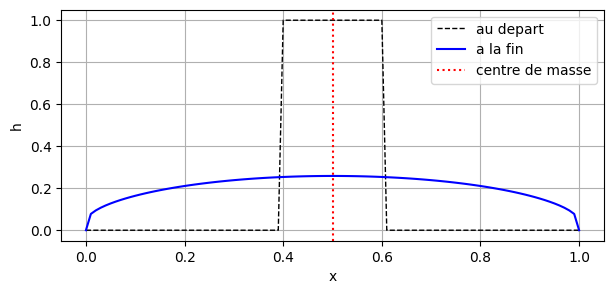

In [4]:
choix =  1       # <<< CHANGEZ CETTE LIGNE :  1 -> moyenne des deux   ou   2 -> cellule de gauche

dt_max = 0.01      # pas de temps maximal
duree  = 1.0       # duree a simuler
temps  = 0.0

h = np.zeros(nx)
h[np.abs(x-0.5) < 0.1] = 1.0
h_ini = np.copy(h)

for it in range(100000):                   # un nombre volontairement tres grand

    if choix == 1:
        hm = 0.5*( h[1:] + h[:-1] )        # la moyenne des deux cellules
    else:
        hm = h[:-1]                        # seulement celle de gauche

    D  = k * hm**2                         # D depend de la solution : recalcule a chaque tour
    dt = min(dt_max, dx**2/(2.1*np.max(np.abs(D))))
    if it == 0:
        dt_debut = dt

    qx       = - D * ( h[1:] - h[:-1] )/dx
    h[1:-1] += - dt*( qx[1:] - qx[:-1] )/dx
    temps   += dt

    if temps > duree:                      # on sort des que la duree est atteinte
        break

centre = np.sum(x*h)/np.sum(h)
print("iterations :", it)
print("dt est passe de", round(dt_debut, 6), "a", round(dt, 6))
print("centre de masse :", round(centre, 4), "  (il devrait valoir 0.5)")

plt.figure(figsize=(7,3))
plt.plot(x, h_ini, 'k--', linewidth=1, label='au depart')
plt.plot(x, h, 'b', label='a la fin')
plt.axvline(centre, color='r', linestyle=':', label='centre de masse')
plt.xlabel('x')
plt.ylabel('h')
plt.legend()
plt.grid(True)
plt.show()

Avec `choix = 1`, le centre de masse reste à **0.5000** : la solution est restée symétrique, comme le problème qu'elle décrit. Le pas de temps, lui, a augmenté d'un facteur 15 au fil des itérations — la solution s'aplatit, `D` diminue, et la contrainte de stabilité se relâche. C'est exactement ce qu'aucun `nt` calculé à l'avance n'aurait pu prévoir.

Avec `choix = 2`, le centre de masse a dérivé à **0.6590** : le modèle a inventé un mouvement d'ensemble qui n'existe pas dans l'équation.

Et surtout, **rien n'a explosé** : aucune erreur n'a été levée, le nombre d'itérations est resté raisonnable, et le profil final a l'air parfaitement plausible. C'est ce qui rend cette erreur bien plus dangereuse que celle du tutoriel 9, où le calcul partait immédiatement à l'infini.

**D'où le réflexe : quand le problème est symétrique, vérifiez que la solution l'est aussi.**